# Lab 1 — Visualization notebook

**This notebook is a working tool, not a deliverable — you do NOT submit it.**

It contains no logic of its own: it imports your finished functions from `../src/lab01.py`
and plots their output. If a cell below fails, the bug is in your `.py`, not in the plot.

Your job: complete the three plot cells, then **export each figure and paste it into
`report.pdf`** (right-click → Save image as…, or `plt.savefig('fig1.png', dpi=150)`).
Figures 1–3 are required by the report template.

In [1]:
import sys
sys.path.insert(0, '../src')
import matplotlib.pyplot as plt
import lab01

raw = lab01.load_data('../data/cafe_sales.csv')
clean = lab01.clean_data(raw)
raw.head()

,order_id,date,item,category,unit_price,quantity,total_price,customer_rating,takeout
0,1272,2026-09-11,cold brew,coffee,5500,1.0,5500.0,3.1,yes
1,1055,2026-09-24,tiramisu,dessert,7000,3.0,21000.0,4.2,no
2,1238,2026-09-18,cold brew,coffee,5500,1.0,5500.0,4.1,no
3,1033,2026-09-25,cold brew,coffee,"5,500",3.0,16500.0,4.2,no
4,1286,2026-09-02,americano,coffee,4500,2.0,9000.0,3.7,yes


## Plot 1 — Missing values per column (raw data)

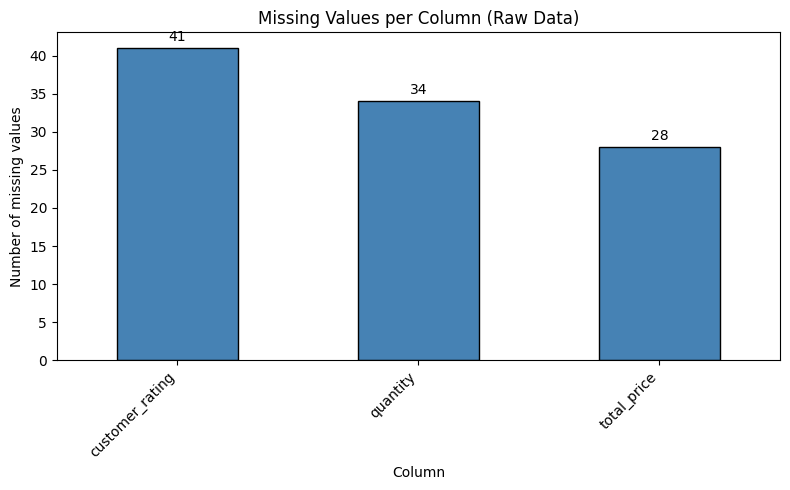

In [4]:
# ============ TODO (Plot 1) ============
missing = lab01.summarize_missing(raw)
fig, ax = plt.subplots(figsize=(8,5))
missing.plot(kind="bar", ax=ax, color="steelblue",  edgecolor="black")

ax.set_xlabel("Column")
ax.set_ylabel("Number of missing values")
ax.set_title("Missing Values per Column (Raw Data)")

ax.tick_params(axis="x", rotation=45)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.bar_label(ax.containers[0], padding=3)

fig.tight_layout()

fig.savefig(
    "fig1_missing_values.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
# =======================================


## Plot 2 — Distribution of `total_price` (clean data)

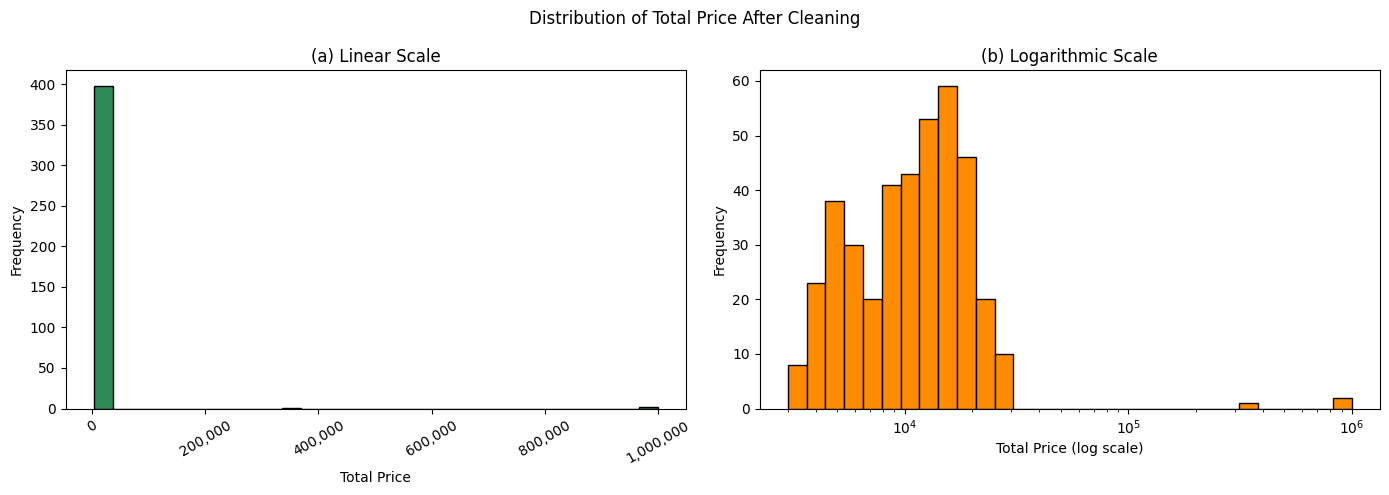

In [8]:
# ============ TODO (Plot 2) ============
# Most orders are concentrated at lower total_price values, while a few bulk orders create a long tail toward much higher values.
# The logarithmic scale makes ordinary orders easier to inspect without excluding any observations.
import numpy as np
from matplotlib.ticker import FuncFormatter

total_prices = clean["total_price"]

log_bins = np.logspace(
    np.log10(total_prices.min()),
    np.log10(total_prices.max()),
    31
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

# (a) Original linear scale
axes[0].hist(
    total_prices,
    bins=30,
    color="seagreen",
    edgecolor="black"
)

axes[0].set_xlabel("Total Price")
axes[0].set_ylabel("Frequency")
axes[0].set_title("(a) Linear Scale")

axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

axes[0].tick_params(
    axis="x",
    rotation=30
)

# (b) Logarithmic scale
axes[1].hist(
    total_prices,
    bins=log_bins,
    color="darkorange",
    edgecolor="black"
)

axes[1].set_xscale("log")
axes[1].set_xlabel("Total Price (log scale)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("(b) Logarithmic Scale")

fig.suptitle(
    "Distribution of Total Price After Cleaning"
)

fig.tight_layout()

fig.savefig(
    "fig2_total_price_histogram.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
# =======================================


## Plot 3 — `customer_rating` by category (clean data)

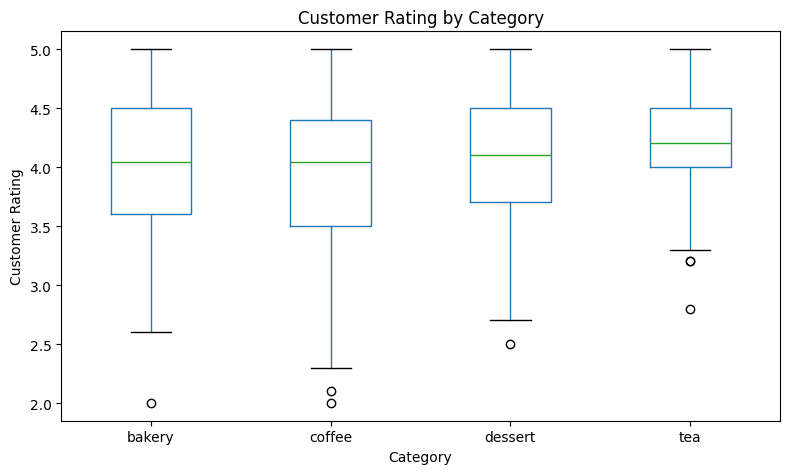

In [6]:
# ============ TODO (Plot 3) ============
fig, ax = plt.subplots(figsize=(8, 5))

clean.boxplot(
    column="customer_rating",
    by="category",
    ax=ax,
    grid=False
)

fig.suptitle("")

ax.set_xlabel("Category")
ax.set_ylabel("Customer Rating")
ax.set_title("Customer Rating by Category")

fig.tight_layout()

fig.savefig(
    "fig3_rating_by_category.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
# =======================================
